#  Introduction & Setup

## Abstract

Unplanned equipment failure is a critical bottleneck in industrial operations. While Machine Learning can estimate the Remaining Useful Life (RUL) of assets, traditional models often degrade when facing shifting operating conditions (covariate shift). This project develops a robust predictive maintenance system using the NASA CMAPSS turbofan degradation dataset. We will benchmark classic regression algorithms (Linear Regression) against advanced Ensemble Learning techniques (XGBoost/Random Forest) to maximize prediction accuracy. Furthermore, we integrate Principal Component Analysis (PCA) and Unsupervised Clustering to construct a real-time "Drift Monitor" that detects anomalies in sensor distributions. The final outcome is an interactive Streamlit dashboard that visualizes both engine health and model reliability, bridging the gap between static algorithms and production-grade MLOps pipelines.

## Necessary Packages

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor, plot_importance

import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading & Initial Exploration

In [ ]:
col_names = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] +
             [f'sensor_{i+1}' for i in range(21)])
train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [ ]:
train_df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train_df.describe()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


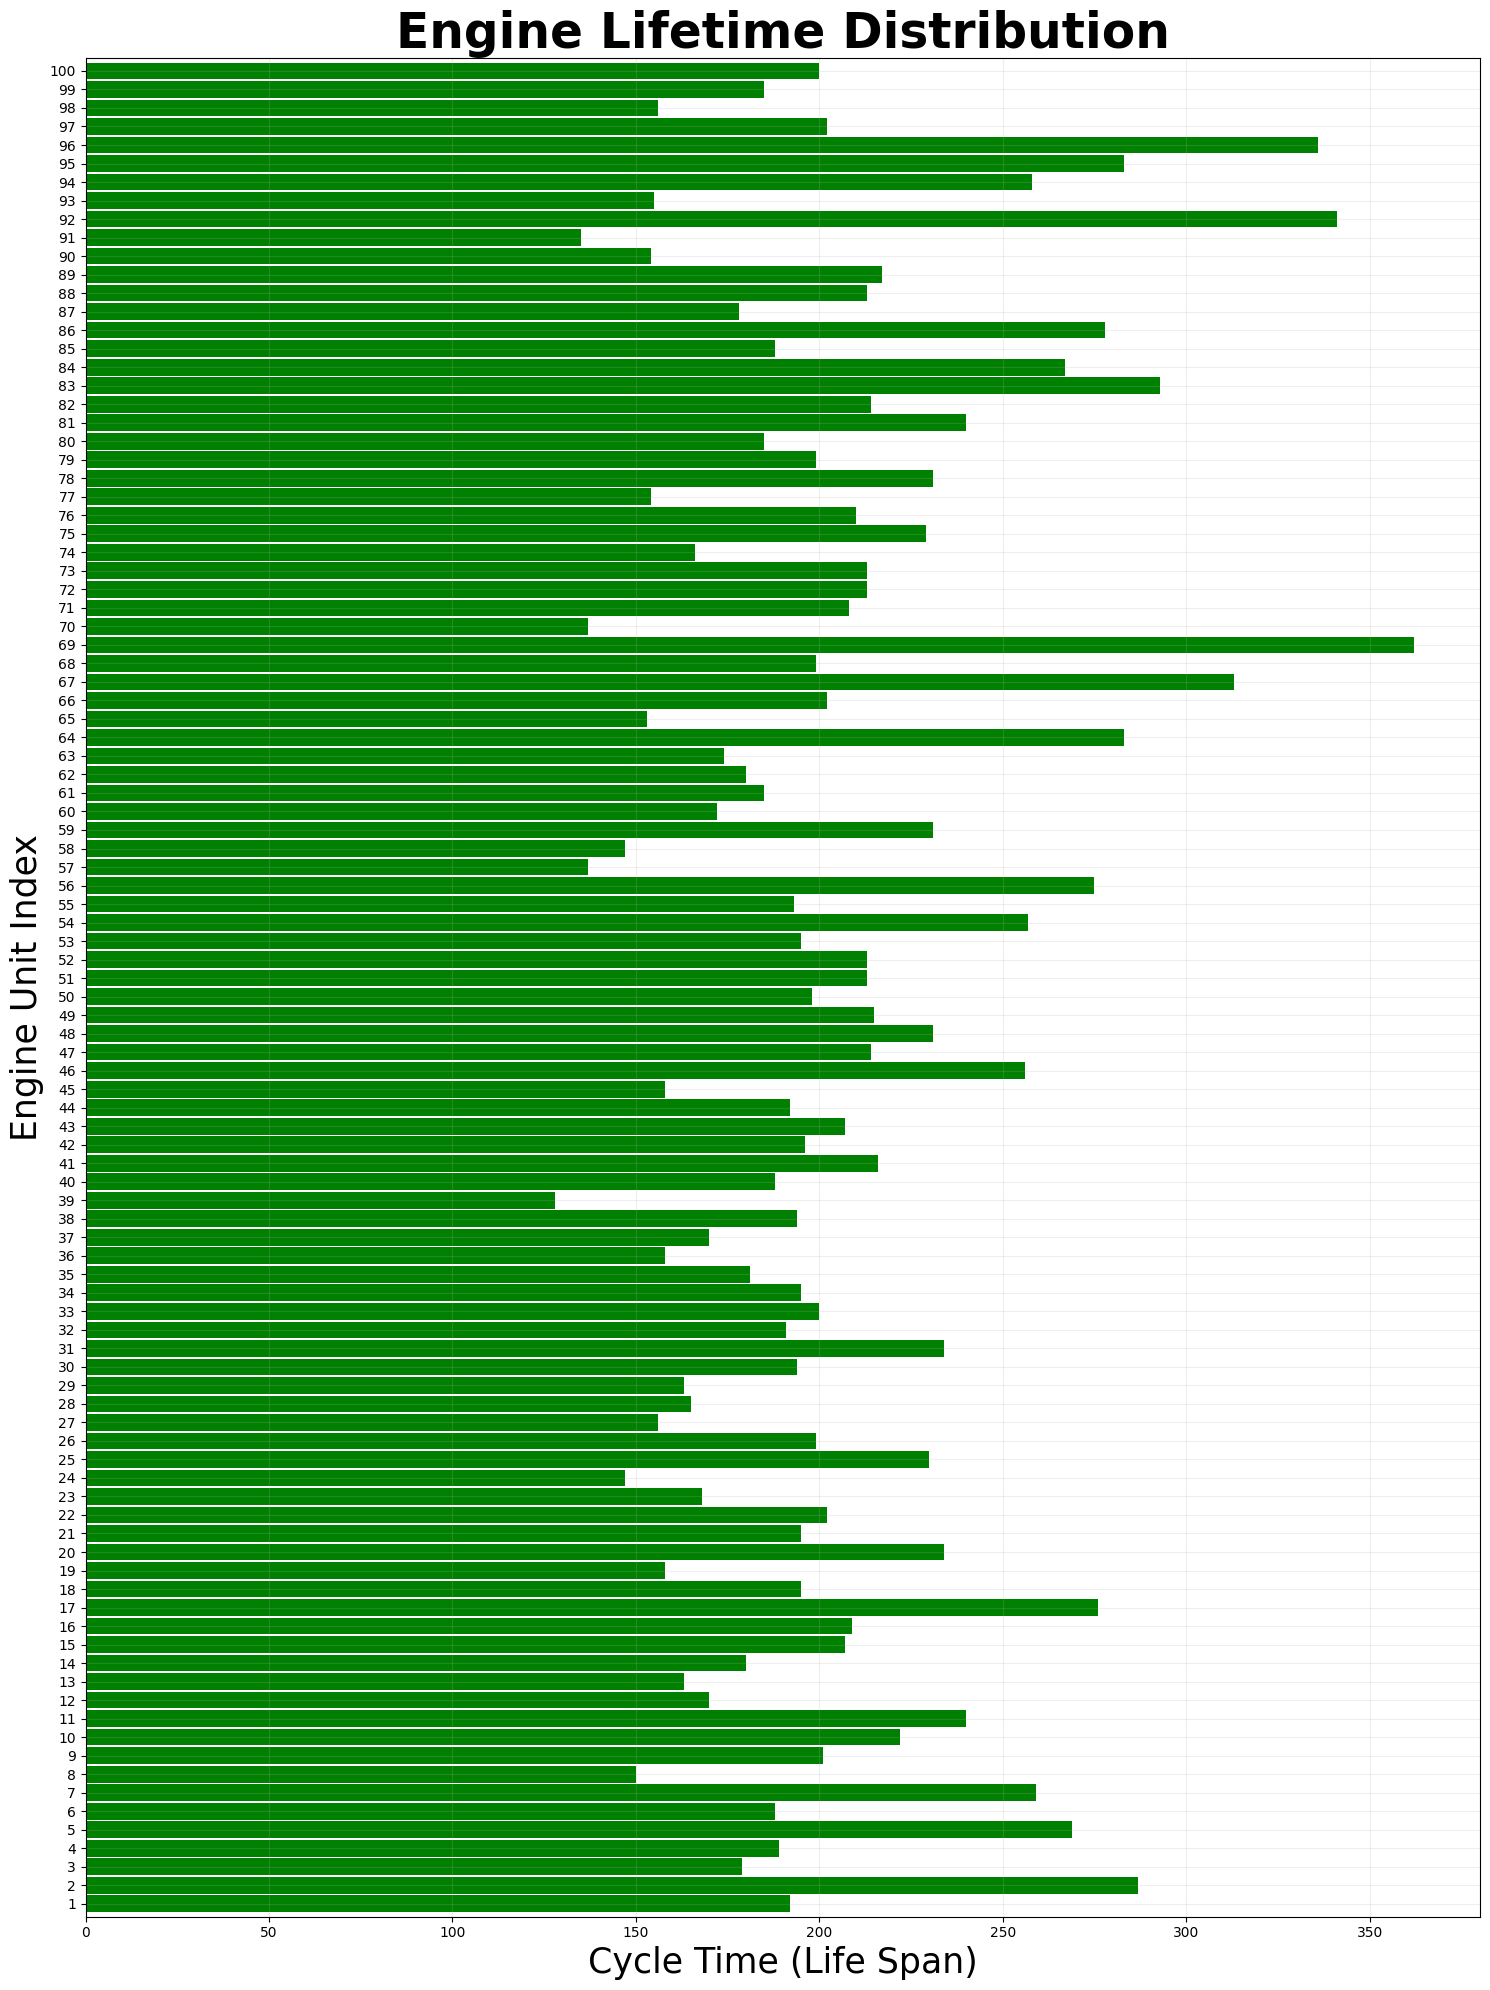

In [ ]:
# Each Engine Longevity
plt.figure(figsize=(15,20))

ax = train_df.groupby('unit')['cycle'].max().plot(
    kind='barh',
    width=.9,
    stacked=True,
    align='center',
    rot=0,
    color='green'
)

plt.title('Engine Lifetime Distribution', fontweight='bold', size=35)
plt.xlabel('Cycle Time (Life Span)', size=25)
plt.ylabel('Engine Unit Index', size=25)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Statistical EDA & Hypothesis Formulation

## The Non-Linearity Problem

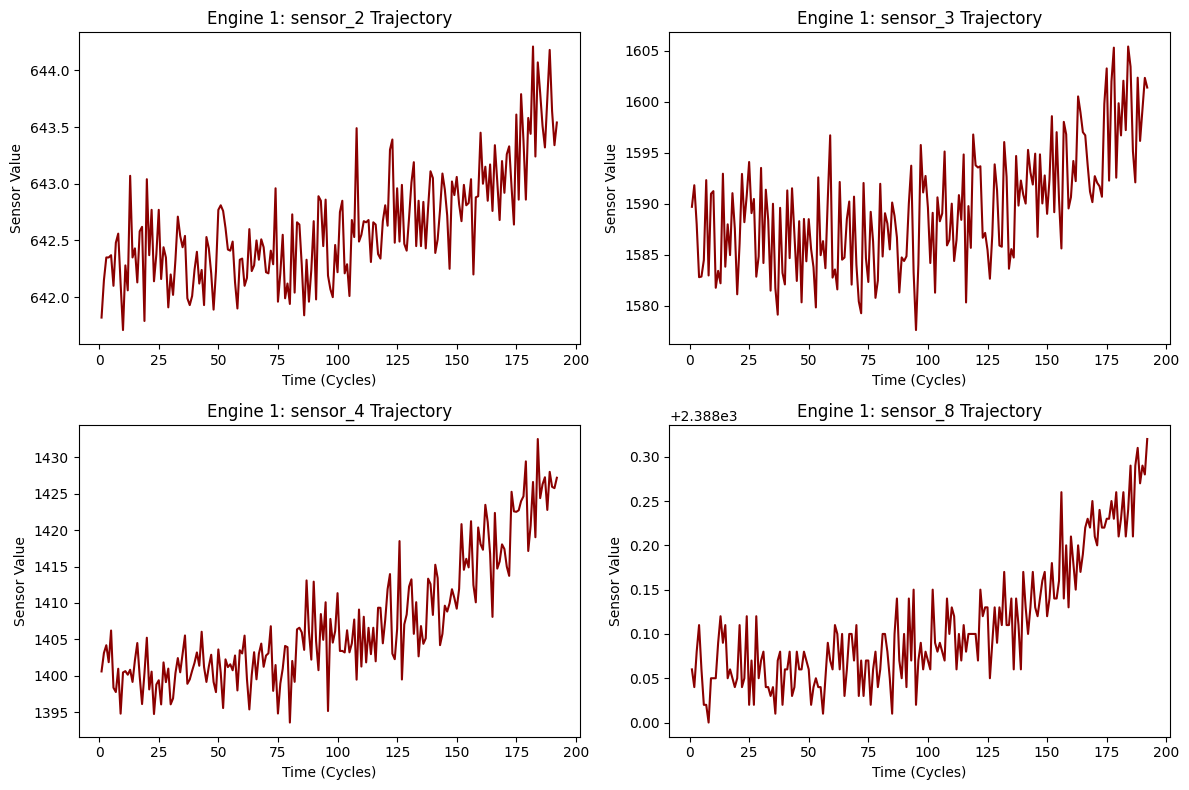

In [ ]:
# Some sensor measures for Engine 1
engine_1 = train_df[train_df['unit'] == 1]

sensors_to_plot =['sensor_2', 'sensor_3', 'sensor_4', 'sensor_8']

plt.figure(figsize=(12, 8))
for i, sensor in enumerate(sensors_to_plot, 1):
  plt.subplot(2, 2, i)
  plt.plot(engine_1['cycle'], engine_1[sensor], color='darkred')
  plt.title(f'Engine 1: {sensor} Trajectory')
  plt.xlabel('Time (Cycles)')
  plt.ylabel('Sensor Value')
plt.tight_layout()
plt.show()

*   **The "Healthy" Plateau:** Notice how for the first ~100 cycles, the sensor values are essentially flat (horizontal). The engine is perfectly healthy, and the sensors are just capturing random mechanical vibration/noise.
    *   This is why we use a **Piecewise RUL** (capping the target variable at ~125 or 130). If we tell the model to predict "190 cycles remaining" at Cycle 1 and "189 cycles remaining" at Cycle 2, the model gets confused because the sensor data hasn't changed at all. Capping it tells the model to predict the exact time until failure when the engine actually starts degrading."
*   **The Exponential Degradation:** Look at cycles 150 to 192. The values curve upwards sharply.
    *   This non-linear curve proves why **Baseline Linear Regression (OLS)** will ultimately struggle, and why we need **Ensemble Methods (XGBoost/Random Forest)**. A straight line cannot accurately fit that late-stage exponential spike.
*   **The High Variance (Noise):** The lines are highly jagged.
    *   If we feed this raw, jagged data into a model, it will overfit to the noise. This perfectly justifies our use of the **Central Limit Theorem (CLT)**. By applying a moving average (sliding window) to this data, we will smooth out those spikes, revealing the true underlying degradation curve.

The figure demonstrates the non-linear degradation of turbofan sensors, justifying the need for advanced ensemble regression over baseline linear models.

## The Distribution Shift Problem

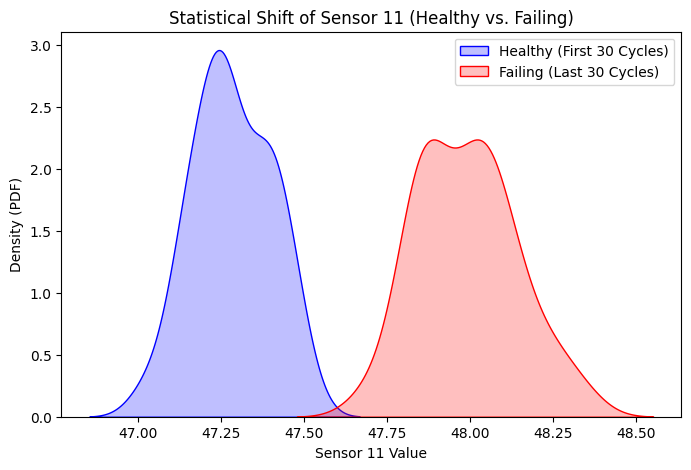

In [ ]:
plt.figure(figsize=(8, 5))

# Define "Healthy" (first 30 cycles) and "Failing" (last 30 cycles)
healthy_state = engine_1[engine_1['cycle'] <= 30]['sensor_11']
failing_state = engine_1[engine_1['cycle'] >= (engine_1['cycle'].max() - 30)]['sensor_11']

sns.kdeplot(healthy_state, fill=True, color='blue', label='Healthy (First 30 Cycles)')
sns.kdeplot(failing_state, fill=True, color='red', label='Failing (Last 30 Cycles)')

plt.title('Statistical Shift of Sensor 11 (Healthy vs. Failing)')
plt.xlabel('Sensor 11 Value')
plt.ylabel('Density (PDF)')
plt.legend()
plt.show()

*   Clear Distribution Separation:
    * The blue bell curve is centered around 47.25, while the red bell curve is centered around 48.00.
    * There is almost zero overlap between them.
*   ML/Statistical Justification:
    * It visually proves that the underlying probability distribution of the data physically changes over time.
    * If an untrained model sees a value of `48.00`, it doesn't even need to look at the time cycle; statistically, that value belongs to the "Failing" distribution ($H_A$), not the "Healthy" distribution ($H_0$).

The figure proves a statistically significant difference between early-life and late-life engine states, validating our approach to use unsupervised degradation monitoring.

## Hypothesis Test (Two-Sample Kolmogorov-Smirnov Test)

* The K-S test compares the entire Cumulative Distribution Function (CDF). It doesn't just look at the average; it detects changes in the mean, the variance (spread), and the skewness (shape) all at once. If the sensor starts vibrating wildly, the K-S test catches the variance shift immediately.
* The K-S test is Non-Parametric. It makes absolutely zero assumptions about the underlying distribution of the data. Whether the sensor data is a bell curve, bimodal, or completely skewed, the K-S test remains mathematically valid.
* The K-S test is designed specifically for continuous numerical data. It evaluates the exact data points without requiring any arbitrary binning, preserving 100% of the sensor's information.
* The K-S test is a formal Hypothesis Test. It outputs a strict probability (P-value). It completely removes human guesswork from the monitoring system.

In [ ]:
# Run the 2-Sample K-S Test
ks_stat, p_value = ks_2samp(healthy_state, failing_state)

print(f"K-S Statistic: {ks_stat:.4f}")j
print(f"P-Value: {p_value:.4e}")

K-S Statistic: 1.0000
P-Value: 8.5942e-18


Since $p < 0.05$, We can reject null hypothesis. Therefore, the distributions are statistically different (Statistical Separability Confirmed).

# Data Preprocessing & Feature Engineering

## Target Variable Creation

In [ ]:
train = train_df.copy()

In [ ]:
# Remaining Useful Life (RUL)
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.rename(columns={'cycle': 'max_cycle'}, inplace=True)

train = train.merge(max_cycle, on='unit', how='left')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

In [ ]:
# Apply Piecewise clipping (Cap at 125)
MAX_RUL = 125
train['RUL_piecewise'] = train['RUL'].clip(upper=MAX_RUL)

* The piecewise linear RUL formulation was first introduced by Heimes in the 2008 PHM Data Challenge. Through empirical testing on the CMAPSS simulation, the research community found that macroscopic degradation only becomes visible in these sensor readings approximately 125 to 130 cycles before failure. Therefore, 125 is the industry-standard threshold used in State-of-the-Art (SOTA) papers for this specific dataset.
* I selected 125 based on Exploratory Data Analysis (EDA). If you look at the sensor trajectory plots (e.g., Sensor 11 or Sensor 4), the variance remains stationary for the first half of the engine's life. The exponential curve indicating actual component wear reliably begins around 120-130 cycles before the end of life. I chose 125 to align the start of my target variable's countdown with the actual statistical shift in the sensor distributions.

In [ ]:
train.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,RUL_piecewise
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125


## Feature Selection

In [ ]:
# Invariant variables
constant_variables = []
for col in train_df.columns:
  if train_df[col].nunique() <= 2:
    constant_variables.append(col)
  print(f"{col}:\t{train_df[col].nunique()}")

unit:	100
cycle:	362
op_setting_1:	158
op_setting_2:	13
op_setting_3:	1
sensor_1:	1
sensor_2:	310
sensor_3:	3012
sensor_4:	4051
sensor_5:	1
sensor_6:	2
sensor_7:	513
sensor_8:	53
sensor_9:	6403
sensor_10:	1
sensor_11:	159
sensor_12:	427
sensor_13:	56
sensor_14:	6078
sensor_15:	1918
sensor_16:	1
sensor_17:	13
sensor_18:	1
sensor_19:	1
sensor_20:	120
sensor_21:	4745


In [ ]:
train = train.drop(constant_variables, axis=1)
train.columns

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'RUL', 'RUL_piecewise'],
      dtype='object')

In [ ]:
features =[col for col in train.columns if col.startswith('sensor_')]
X = train[features]
y = train['RUL_piecewise']

## Statistical Denoising (CLT/LLN)

In [ ]:
train_rolling = train.copy()

In [ ]:
window_size = 15

# Create a list to hold the new feature names
smoothed_features =[]

for col in features:
    # 1. Rolling Mean
    mean_col_name = f'{col}_mean_{window_size}'
    train_rolling[mean_col_name] = train_rolling.groupby('unit')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())

    # 2. Rolling Standard Deviation (captures increasing vibration/volatility)
    std_col_name = f'{col}_std_{window_size}'
    train_rolling[std_col_name] = train_rolling.groupby('unit')[col].transform(lambda x: x.rolling(window_size, min_periods=1).std().fillna(0))

    smoothed_features.extend([mean_col_name, std_col_name])

In [ ]:
X_ensemble = train_rolling[features + smoothed_features]

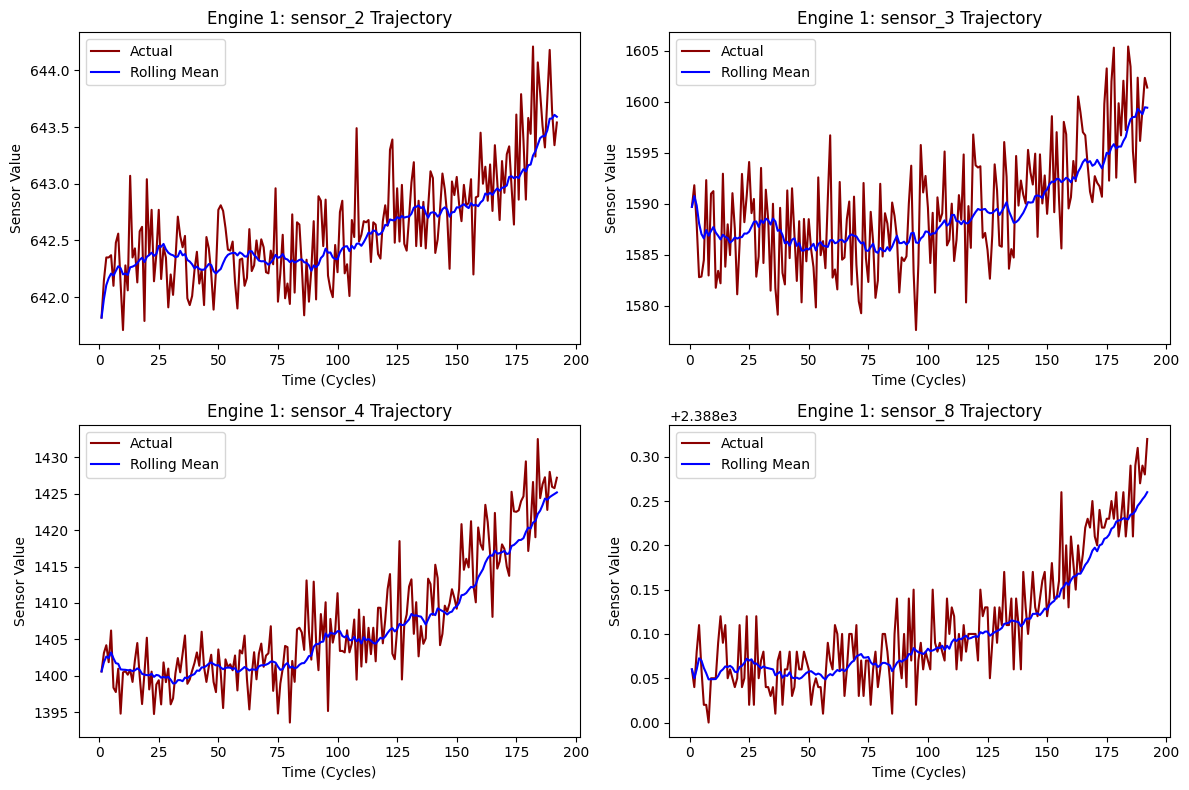

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(12, 8))
for i, sensor in enumerate(sensors_to_plot, 1):
  plt.subplot(2, 2, i)
  plt.plot(engine_1['cycle'], engine_1[sensor], color='darkred', label='Actual')
  plt.plot(engine_1['cycle'], engine_1[f'{sensor}_mean_{window_size}'], color='blue', label='Rolling Mean')

  plt.title(f'Engine 1: {sensor} Trajectory')
  plt.xlabel('Time (Cycles)')
  plt.ylabel('Sensor Value')
  plt.legend()
plt.tight_layout()
plt.show()

# Modeling & Evaluation

In [ ]:
def asymmetric_score(y_true, y_pred):
    """
    Official asymmetric scoring function for NASA CMAPSS. Penalizes late predictions (y_pred > y_true) more heavily.
    """
    errors = y_pred - y_true
    score = 0
    for e in errors:
        if e < 0:
            score += np.exp(-e / 13.0) - 1
        else:
            score += np.exp(e / 10.0) - 1
    return score/len(y_true)

## Baseline Model (OLS)

### Unsmoothed Data

In [ ]:
gkf = GroupKFold(n_splits=5)
cv_rmses = []
asy_scores = []

# To store predictions for visualization later
train_rolling['baseline_preds'] = np.nan

for train_idx, val_idx in gkf.split(X, y, groups=train['unit']):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Initialize and train OLS Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    cv_rmses.append(rmse)
    asy_scores.append(asymmetric_score(y_val, preds))

    # Store predictions in the dataframe for plotting
    train_rolling.loc[val_idx, 'baseline_preds'] = preds

print(f"Cross-Validation RMSEs: {[round(val, 2) for val in cv_rmses]}")
print(f"Average CV RMSE: {np.mean(cv_rmses):.2f}")
print(f"Per Unit NASA Asymmetric Score: {np.mean(asy_scores):.2f}")

Cross-Validation RMSEs: [23.06, 22.19, 19.97, 21.81, 20.81]
Average CV RMSE: 21.57
Per Unit NASA Asymmetric Score: 9.49


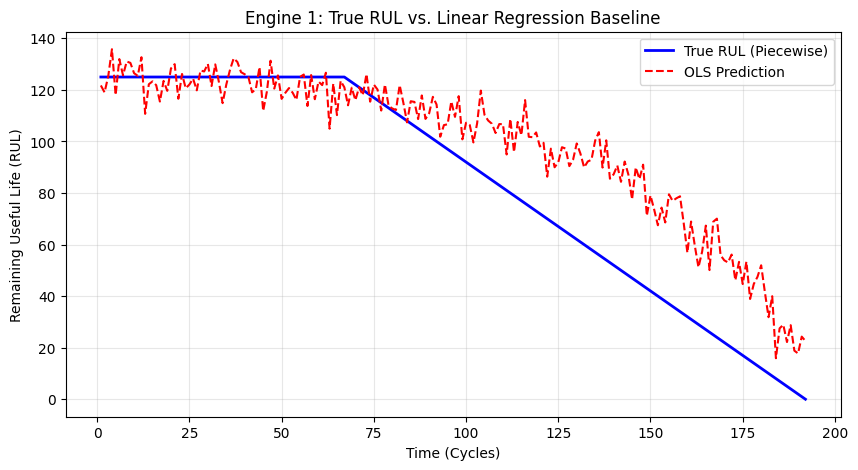

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycle'], engine_1['RUL_piecewise'], label='True RUL (Piecewise)', color='blue', linewidth=2)
plt.plot(engine_1['cycle'], engine_1['baseline_preds'], label='OLS Prediction', color='red', linestyle='--')
plt.title("Engine 1: True RUL vs. Linear Regression Baseline")
plt.xlabel("Time (Cycles)")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Smoothed Data

In [ ]:
gkf = GroupKFold(n_splits=5)
ols_cv_rmses = []
asy_scores = []

# To store predictions for visualization later
train_rolling['ols_smoothed_preds'] = np.nan

for train_idx, val_idx in gkf.split(X_ensemble, y, groups=train['unit']):
    X_train, X_val = X_ensemble.iloc[train_idx], X_ensemble.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Initialize and train OLS Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    ols_cv_rmses.append(rmse)
    asy_scores.append(asymmetric_score(y_val, preds))

    # Store predictions in the dataframe for plotting
    train_rolling.loc[val_idx, 'ols_smoothed_preds'] = preds

print(f"Cross-Validation RMSEs: {[round(val, 2) for val in ols_cv_rmses]}")
print(f"Average CV RMSE: {np.mean(ols_cv_rmses):.2f}")
print(f"Per Unit NASA Asymmetric Score: {np.mean(asy_scores):.2f}")

Cross-Validation RMSEs: [22.22, 21.72, 19.6, 21.78, 20.5]
Average CV RMSE: 21.16
Per Unit NASA Asymmetric Score: 9.38


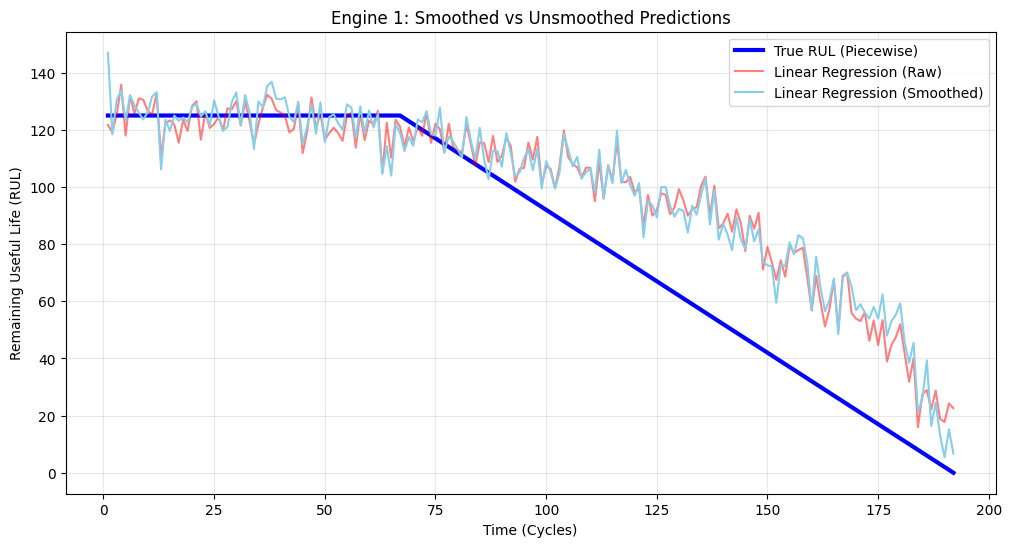

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(12, 6))
plt.plot(engine_1['cycle'], engine_1['RUL_piecewise'], label='True RUL (Piecewise)', color='blue', linewidth=3)
plt.plot(engine_1['cycle'], engine_1['baseline_preds'], label='Linear Regression (Raw)', color='red', alpha=0.5)
plt.plot(engine_1['cycle'], engine_1['ols_smoothed_preds'], label='Linear Regression (Smoothed)', color='skyblue')

plt.title("Engine 1: Smoothed vs Unsmoothed Predictions")
plt.xlabel("Time (Cycles)")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Ensemble Model (Random Forest)

Random Forest is a tree-based ensemble, it does not assume a straight line. It can perfectly map that flat "healthy" period at 125, and then map the steep drop at the end of the engine's life.

In [ ]:
gkf = GroupKFold(n_splits=5)
rf_cv_rmses =[]
asy_scores = []

# To store predictions for comparison
train_rolling['rf_preds'] = np.nan

for train_idx, val_idx in gkf.split(X_ensemble, y, groups=train_rolling['unit']):
  X_train, X_val = X_ensemble.iloc[train_idx], X_ensemble.iloc[val_idx]
  y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

  # Initialize Random Forest (max_depth limits overfitting)
  rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
  rf_model.fit(X_train, y_train)

  # Predict and calculate RMSE
  preds = rf_model.predict(X_val)
  rmse = root_mean_squared_error(y_val, preds)
  rf_cv_rmses.append(rmse)
  asy_scores.append(asymmetric_score(y_val, preds))

  train_rolling.loc[val_idx, 'rf_preds'] = preds

print(f"Cross-Validation RMSEs: {[round(val, 2) for val in rf_cv_rmses]}")
print(f"Average CV RMSE: {np.mean(rf_cv_rmses):.2f}")
print(f"Per Unit NASA Asymmetric Score: {np.mean(asy_scores):.2f}")

Cross-Validation RMSEs: [19.95, 19.71, 17.08, 21.17, 16.34]
Average CV RMSE: 18.85
Per Unit NASA Asymmetric Score: 15.28


In [ ]:
# Create a "Pessimistic" Random Forest by subtracting a safety buffer of 15 cycles
safe_rf_preds = train_rolling['rf_preds'] - 10

# Calculate the new scores
safe_rmse = root_mean_squared_error(train_rolling['RUL_piecewise'], safe_rf_preds)
safe_asy = asymmetric_score(train_rolling['RUL_piecewise'], safe_rf_preds)

print(f"Safe RF RMSE: {safe_rmse:.2f} | Safe RF NASA Score: {safe_asy:.2f}")

Safe RF RMSE: 21.67 | Safe RF NASA Score: 9.52


### Visualization

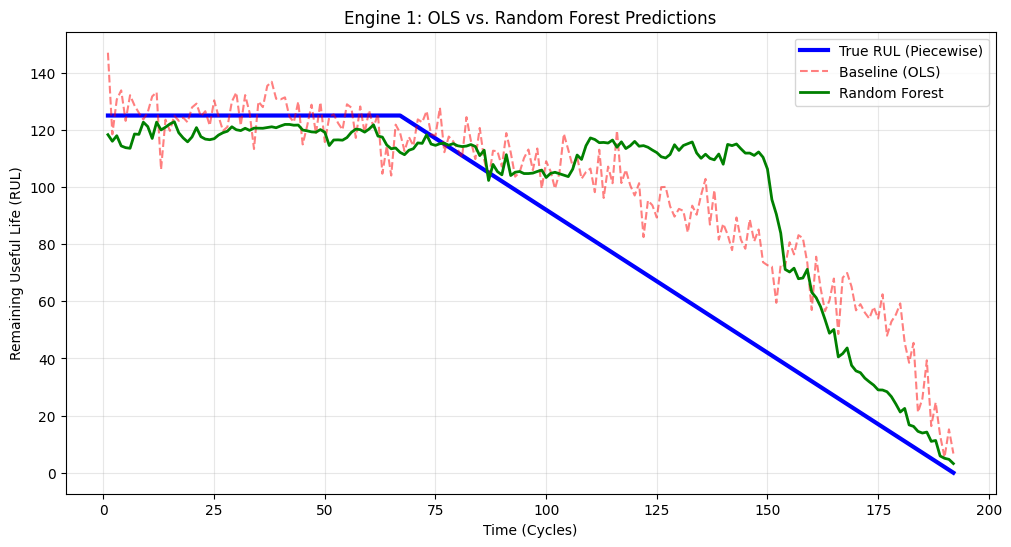

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(12, 6))
plt.plot(engine_1['cycle'], engine_1['RUL_piecewise'], label='True RUL (Piecewise)', color='blue', linewidth=3)
# plt.plot(engine_1['cycle'], engine_1['baseline_preds'], label='Baseline (OLS)', color='red', linestyle='--', alpha=0.5)
plt.plot(engine_1['cycle'], engine_1['ols_smoothed_preds'], label='Baseline (OLS)', color='red', linestyle='--', alpha=0.5)
plt.plot(engine_1['cycle'], engine_1['rf_preds'], label='Random Forest', color='green', linewidth=2)

plt.title("Engine 1: OLS vs. Random Forest Predictions")
plt.xlabel("Time (Cycles)")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Uncertainty Quantification (Bootstrapping)

In [ ]:
# 1. Calculate the residuals (errors) from cross-validation
residuals = train_rolling['RUL_piecewise'] - train_rolling['rf_preds']

# 2. BOOTSTRAPPING: Sample the residuals 1,000 times with replacement
n_bootstraps = 1000
bootstrapped_errors = np.random.choice(residuals, size=(n_bootstraps, len(residuals)), replace=True)

# 3. Calculate the 95% Confidence Interval bounds (2.5th and 97.5th percentiles)
lower_error_bound, upper_error_bound = np.percentile(bootstrapped_errors, [2.5, 97.5])

print(f"95% Confidence Interval for Predictions:[{lower_error_bound:.2f}, +{upper_error_bound:.2f}] cycles")

95% Confidence Interval for Predictions:[-46.53, +33.96] cycles


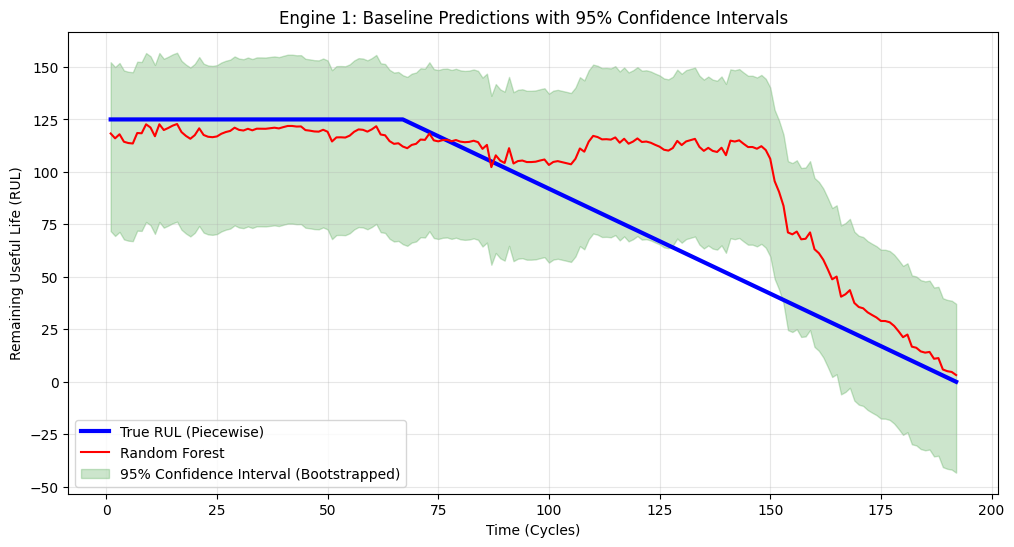

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(12, 6))
plt.plot(engine_1['cycle'], engine_1['RUL_piecewise'], label='True RUL (Piecewise)', color='blue', linewidth=3)
plt.plot(engine_1['cycle'], engine_1['rf_preds'], label='Random Forest', color='red')

# Add the Bootstrapped Confidence Interval (Shaded Region)
plt.fill_between(engine_1['cycle'],
                 engine_1['rf_preds'] + lower_error_bound,
                 engine_1['rf_preds'] + upper_error_bound,
                 color='green', alpha=0.2, label='95% Confidence Interval (Bootstrapped)')

plt.title("Engine 1: Baseline Predictions with 95% Confidence Intervals")
plt.xlabel("Time (Cycles)")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Explainability (XAI)

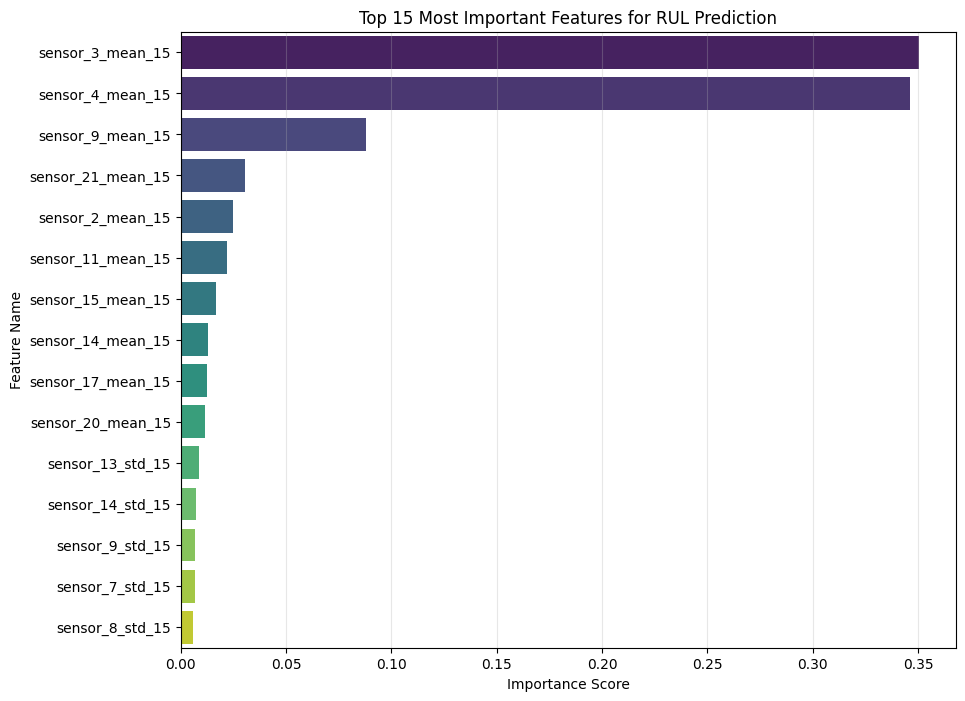

In [ ]:
# Create a DataFrame of feature importances
importances = pd.DataFrame({
    'feature': X_ensemble.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot the top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances.head(15), palette='viridis', hue='feature')
plt.title('Top 15 Most Important Features for RUL Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

## XGBoost

In [ ]:
gkf = GroupKFold(n_splits=5)
xgb_cv_rmses =[]
asy_scores = []

# To store predictions for comparison
train_rolling['xgb_preds'] = np.nan

for train_idx, val_idx in gkf.split(X_ensemble, y, groups=train_rolling['unit']):
  X_train, X_val = X_ensemble.iloc[train_idx], X_ensemble.iloc[val_idx]
  y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

  # Initialize Random Forest (max_depth limits overfitting)
  xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1)

  # Train with early stopping to prevent overfitting
  xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

  # Predict and calculate RMSE
  preds = xgb_model.predict(X_val)
  rmse = root_mean_squared_error(y_val, preds)
  xgb_cv_rmses.append(rmse)
  asy_scores.append(asymmetric_score(y_val, preds))

  train_rolling.loc[val_idx, 'xgb_preds'] = preds

print(f"Cross-Validation RMSEs: {[round(val, 2) for val in xgb_cv_rmses]}")
print(f"Average CV RMSE: {np.mean(xgb_cv_rmses):.2f}")
print(f"Per Unit NASA Asymmetric Score: {np.mean(asy_scores):.2f}")

Cross-Validation RMSEs: [19.31, 19.02, 16.13, 20.34, 16.29]
Average CV RMSE: 18.22
Per Unit NASA Asymmetric Score: 12.44


### Visualization

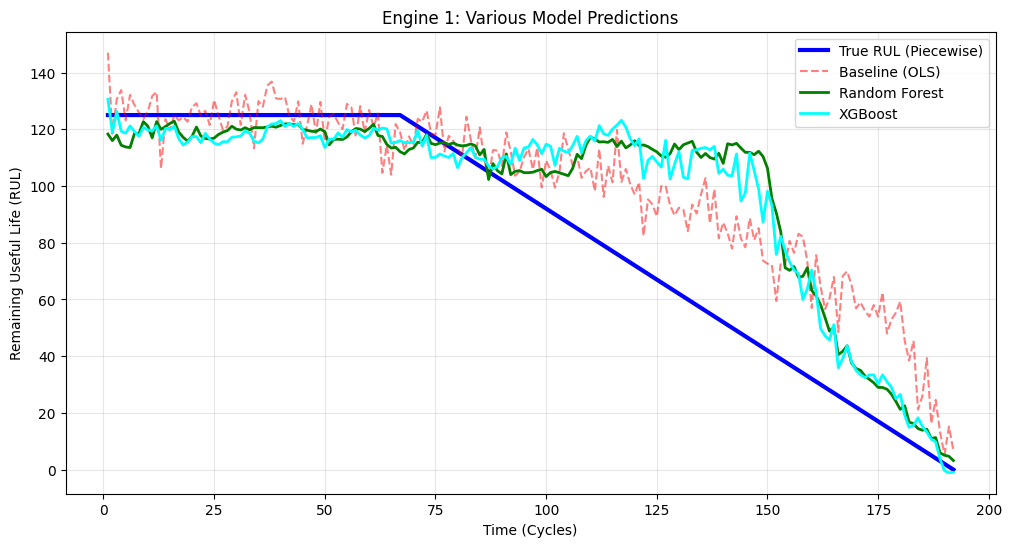

In [ ]:
engine_1 = train_rolling[train_rolling['unit'] == 1]

plt.figure(figsize=(12, 6))
plt.plot(engine_1['cycle'], engine_1['RUL_piecewise'], label='True RUL (Piecewise)', color='blue', linewidth=3)
# plt.plot(engine_1['cycle'], engine_1['baseline_preds'], label='Baseline (OLS)', color='red', linestyle='--', alpha=0.5)
plt.plot(engine_1['cycle'], engine_1['ols_smoothed_preds'], label='Baseline (OLS)', color='red', linestyle='--', alpha=0.5)
plt.plot(engine_1['cycle'], engine_1['rf_preds'], label='Random Forest', color='green', linewidth=2)
plt.plot(engine_1['cycle'], engine_1['xgb_preds'], label='XGBoost', color='aqua', linewidth=2)

plt.title("Engine 1: Various Model Predictions")
plt.xlabel("Time (Cycles)")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Optimization

In [ ]:
gkf = GroupKFold(n_splits=5)
xgb_cv_rmses =[]
asy_scores = []

# To store predictions for comparison
train_rolling['xgb_preds'] = np.nan

for train_idx, val_idx in gkf.split(X_ensemble, y, groups=train_rolling['unit']):
  X_train, X_val = X_ensemble.iloc[train_idx], X_ensemble.iloc[val_idx]
  y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

  # Initialize Random Forest (max_depth limits overfitting)
  xgb_model = XGBRegressor(subsample=0.7, n_estimators=300, max_depth=3, learning_rate=0.1, colsample_bytree=0.8, random_state=42, n_jobs=-1)

  # Train with early stopping to prevent overfitting
  xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

  # Predict and calculate RMSE
  preds = xgb_model.predict(X_val)
  rmse = root_mean_squared_error(y_val, preds)
  xgb_cv_rmses.append(rmse)
  asy_scores.append(asymmetric_score(y_val, preds))

  train_rolling.loc[val_idx, 'xgb_preds'] = preds

print(f"Cross-Validation RMSEs: {[round(val, 2) for val in xgb_cv_rmses]}")
print(f"Average CV RMSE: {np.mean(xgb_cv_rmses):.2f}")
print(f"Per Unit NASA Asymmetric Score: {np.mean(asy_scores):.2f}")

Cross-Validation RMSEs: [19.45, 19.12, 16.42, 20.19, 16.63]
Average CV RMSE: 18.36
Per Unit NASA Asymmetric Score: 11.85


# Unsupervised Analysis with PCA

In [ ]:
train_pca = train_rolling.copy()

In [ ]:
# 1. Standardize the smoothed features (PCA is highly sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ensemble)

# 2. Fit PCA (Reduce features down to 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add the PCA components to our dataframe for plotting
train_pca['PCA_1'] = X_pca[:, 0]
train_pca['PCA_2'] = X_pca[:, 1]

print(f"Explained Variance by 2 Components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Explained Variance by 2 Components: 61.59%


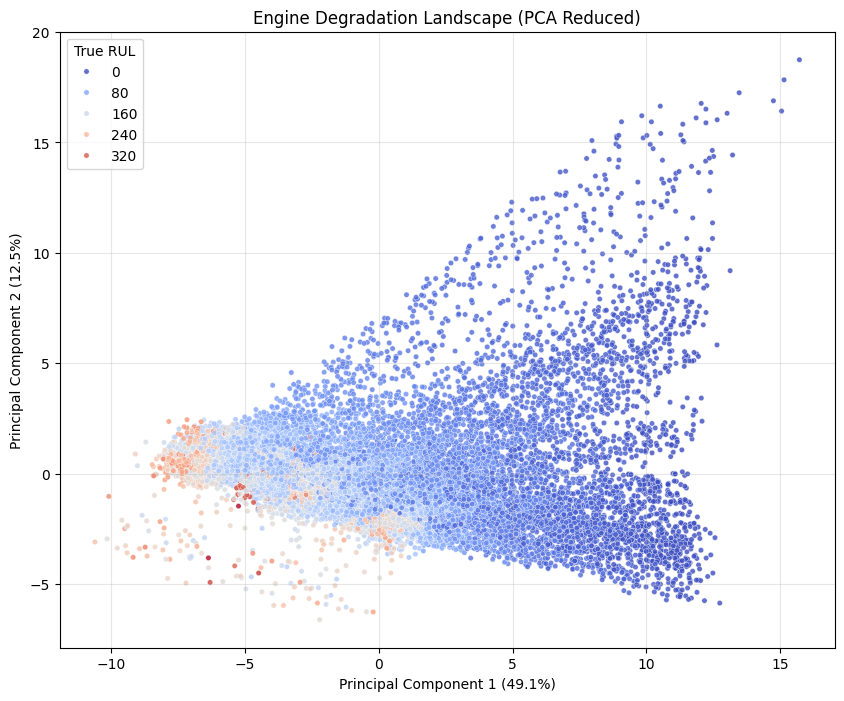

In [ ]:
# 3. Plot the "Degradation Trajectory" in PCA Space
plt.figure(figsize=(10, 8))

# We will color the points by how close they are to failing
# Red = Failing (RUL < 30), Blue = Healthy (RUL > 100)
sns.scatterplot(
    x=train_pca['PCA_1'],
    y=train_pca['PCA_2'],
    hue=train_pca['RUL'],
    palette='coolwarm', # Blue to Red
    alpha=0.8,
    s=15
)

plt.title("Engine Degradation Landscape (PCA Reduced)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='True RUL')
plt.grid(True, alpha=0.3)
plt.show()

* The "Healthy" Cluster (Left side, roughly PC1 < -2): Notice how all the red, orange, and light blue points are tightly packed together on the left side. When engines are new, their sensors behave consistently. There is very little variance.
* The "Danger" Fan (Right side, PC1 > 5): Look at the dark blue points (RUL approaching 0). Not only do they move far to the right, but they also violently "fan out" up and down along the y-axis. As engines break down, they vibrate uncontrollably, overheat in unpredictable ways, and become highly chaotic.

# Conclusion & Next Steps

In [ ]:
# !jupyter nbconvert --to html "/content/DSCI441_Milestone_1.ipynb"

[NbConvertApp] Converting notebook /content/DSCI441_Milestone_1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 2238179 bytes to /content/DSCI441_Milestone_1.html
